In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('parkinsons_disease_data.csv')

## Analysis of Dataset

In [2]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [3]:
display(df.shape)

(2105, 35)

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int64  
 14  Diabetes

None

In [5]:
# Check for null
display(df.isnull().sum().sum())

# Check for duplicates
display(df.duplicated().sum())

np.int64(0)

np.int64(0)

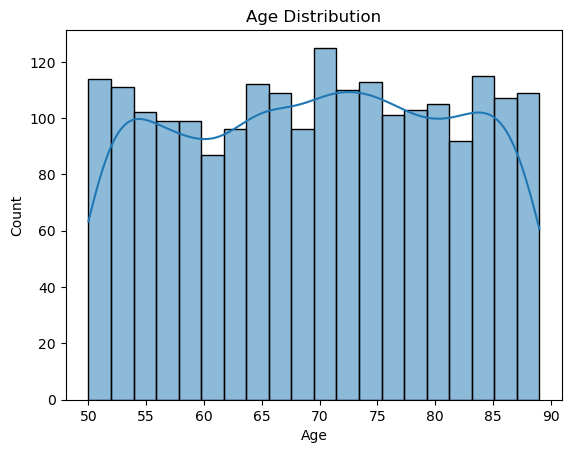

In [6]:
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

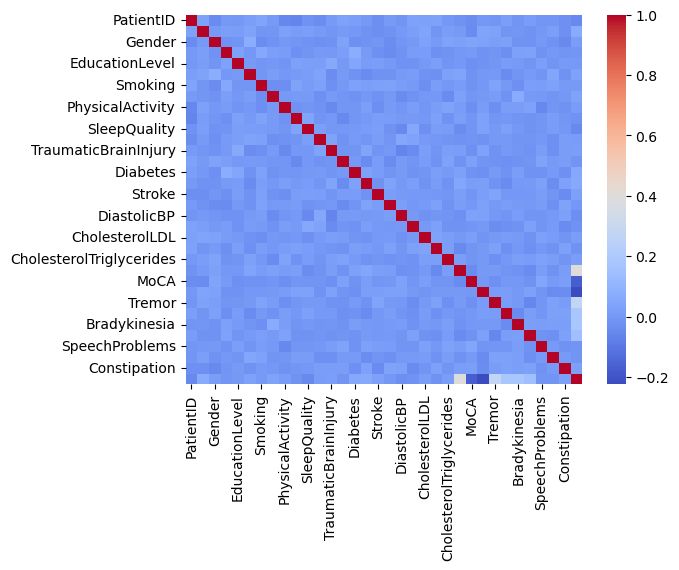

In [7]:
sns.heatmap(df.corr(numeric_only=True), cmap = "coolwarm")
plt.show()

,count
Diagnosis,
1,1304
0,801


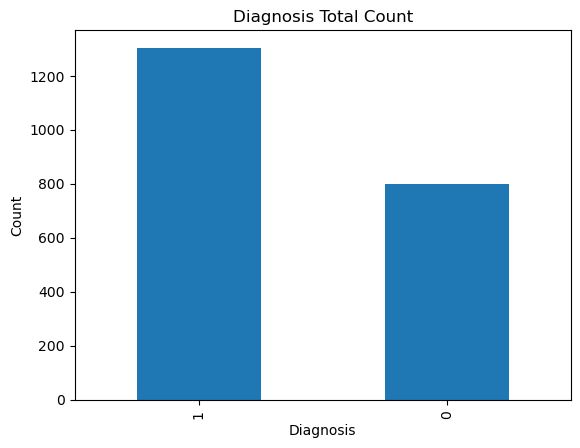

In [8]:
y = df.Diagnosis.value_counts().plot(kind='bar')

plt.ylabel("Count")
plt.title("Diagnosis Total Count")
display(df['Diagnosis'].value_counts().to_frame('count'))

In [9]:
from sklearn.model_selection import train_test_split

# drop patient and doctor columns
df = df.drop(columns=['PatientID', 'DoctorInCharge'])

X = df.drop(columns=['Diagnosis'])
Y = df.Diagnosis

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [10]:
## Preprocessing Dataset

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Resample to balance Dataset
X_train, Y_train = smote.fit_resample(X_train, Y_train)
display(Y_train.value_counts().to_frame('count'))

,count
Diagnosis,
0,1033
1,1033


### Logistic Regression

Training Accuracy: 84.41%
Test Accuracy: 81.00%
              precision    recall  f1-score   support

           0      0.713     0.780     0.745       150
           1      0.872     0.827     0.848       271

    accuracy                          0.810       421
   macro avg      0.793     0.803     0.797       421
weighted avg      0.815     0.810     0.812       421



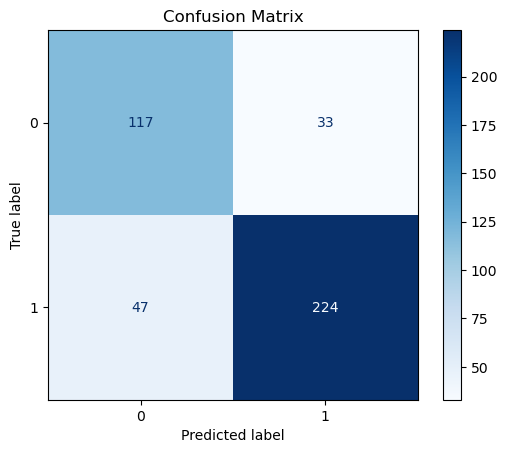

In [13]:
from sklearn.linear_model import LogisticRegression

regressor = LogisticRegression(class_weight='balanced', max_iter=5000)

regressor.fit(X_train, Y_train)

train_accuracy = regressor.score(X_train, Y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

Y_pred = regressor.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

# Get test accuracy
test_accuracy = accuracy_score(Y_test, Y_pred)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

# Get classification report
report = classification_report(Y_test, Y_pred, digits=3)
print(report)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues) 
plt.title("Confusion Matrix")
plt.show() 

### RBF Kernel SVM

              precision    recall  f1-score   support

           0      0.673     0.700     0.686       150
           1      0.830     0.812     0.821       271

    accuracy                          0.772       421
   macro avg      0.752     0.756     0.754       421
weighted avg      0.774     0.772     0.773       421



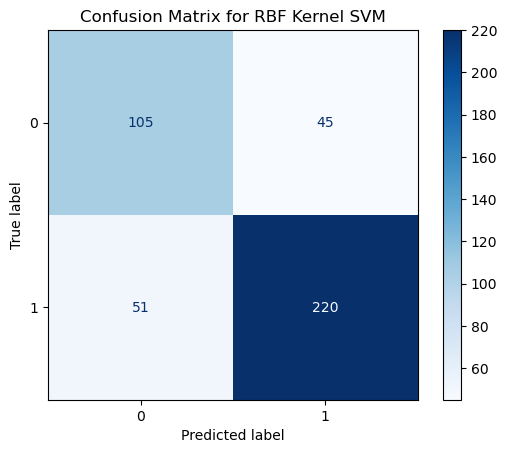

In [14]:
from sklearn.svm import SVC

rbf = SVC(C=1, kernel='rbf', gamma='scale')
rbf.fit(X_train, Y_train)
Y_pred_rbf = rbf.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluation for RBF Kernel SVM
report = classification_report(Y_test, Y_pred_rbf, digits=3)
print(report)

cm = confusion_matrix(Y_test, Y_pred_rbf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues) 
plt.title("Confusion Matrix for RBF Kernel SVM")
plt.show()

### Neural Network Model

In [15]:
from keras.callbacks import ReduceLROnPlateau

display(df.shape)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

(2105, 33)

In [16]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [17]:
from keras.models import Sequential
from keras.layers import *

model = Sequential()

# Add layers
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(128, activation='leaky_relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='leaky_relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='leaky_relu'))

In [18]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
history = model.fit(x=X_train, y=Y_train, batch_size=128, epochs=10, validation_split=0.2, callbacks=[reduce_lr, early_stopping])

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4824 - loss: 4.7707 - val_accuracy: 0.5725 - val_loss: 2.3081 - learning_rate: 0.0010
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6029 - loss: 2.9633 - val_accuracy: 0.4541 - val_loss: 2.5119 - learning_rate: 0.0010
Epoch 3/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6094 - loss: 2.1402
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6507 - loss: 2.6047 - val_accuracy: 0.4372 - val_loss: 2.6544 - learning_rate: 0.0010
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6550 - loss: 2.3369 - val_accuracy: 0.5459 - val_loss: 1.7373 - learning_rate: 5.0000e-04
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6689 - loss: 1.9361 - val_accuracy: 0.7005 - val_loss: 0.9988 - learning_rate: 5.0000e-04
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6822 - loss: 1.7205 - val_a

In [20]:
_, test_accuracy = model.evaluate(X_test, Y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6983 - loss: 1.1049 


In [21]:
print(f'Test Accuracy: {test_accuracy:.3f}')

Test Accuracy: 0.698
